In [1]:
# Step 0: Setup
import pandas as pd
import numpy as np                                                                              
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime

In [3]:
# Step 1: Load Data
df = pd.read_csv("ecommerce_customer_data_large.csv")              
print(df.head())
print(df.info())

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        44605  2023-05-03 21:30:02             Home            177         1   
1        44605  2021-05-16 13:57:44      Electronics            174         3   
2        44605  2020-07-13 06:16:57            Books            413         1   
3        44605  2023-01-17 13:14:36      Electronics            396         3   
4        44605  2021-05-01 11:29:27            Books            259         4   

   Total Purchase Amount Payment Method  Customer Age  Returns Customer Name  \
0                   2427         PayPal            31      1.0   John Rivera   
1                   2448         PayPal            31      1.0   John Rivera   
2                   2345    Credit Card            31      1.0   John Rivera   
3                    937           Cash            31      0.0   John Rivera   
4                   2598         PayPal            31      1.0   John Rivera   

   Age  Gender  Churn  
0   31  

In [4]:
# Step 2: Data Cleaning
df.drop_duplicates(inplace=True)
df.fillna({
    "Age": df["Age"].median(),
    "Gender": df["Gender"].mode()[0],
    "Category": "Unknown"
}, inplace=True)

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,33807,2023-01-24 12:32:18,Home,436,1,3664,Cash,63,0.0,Gabriel Williams,63,Male,0
249996,20455,2021-06-04 05:45:25,Electronics,233,1,4374,Credit Card,66,1.0,Barry Foster,66,Female,0
249997,28055,2022-11-10 17:11:57,Electronics,441,5,5296,Cash,63,NaN,Lisa Johnson,63,Female,0
249998,15023,2021-06-27 14:42:12,Electronics,44,2,2517,Cash,64,1.0,Melissa Fernandez,64,Male,0


In [6]:
print(df.columns.tolist())

['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']


In [8]:
# Step 3: Feature Engineering
today = datetime(2026,8,10)  # analysis date
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Recency"] = (today - df["Purchase Date"]).dt.days

In [11]:
rfm = df.groupby("Customer ID").agg({
    "Recency": "min",                  # already computed earlier
    "Purchase Date": "count",          # frequency = number of purchases
    "Total Purchase Amount": "sum"     # monetary = total spend
}).rename(columns={
    "Purchase Date": "Frequency",
    "Total Purchase Amount": "Monetary"
})


In [12]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

rfm = df.groupby("customer_id").agg({
    "recency": "min",
    "purchase_date": "count",
    "total_purchase_amount": "sum"
}).rename(columns={
    "purchase_date": "frequency",
    "total_purchase_amount": "monetary"
})


In [14]:
# Step 2: RFM Aggregation
rfm = df.groupby("customer_id").agg({
    "recency": "min",                  # days since last purchase
    "purchase_date": "count",          # frequency = number of purchases
    "total_purchase_amount": "sum"     # monetary = total spend
}).rename(columns={
    "purchase_date": "frequency",
    "total_purchase_amount": "monetary"
})

In [15]:
# Step 3: Churn Flag (inactive > 90 days)
rfm["churn_flag"] = np.where(rfm["recency"] > 90, 1, 0)

print(rfm.head())

             recency  frequency  monetary  churn_flag
customer_id                                          
1               1349          3      6290           1
2               1133          6     16481           1
3               1283          4      9423           1
4               1502          5      7826           1
5               1485          5      9769           1


In [17]:
# Step 4: RFM Segmentation
rfm["R_Score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["frequency"], 5, labels=[1,2,3,4,5])
rfm["M_Score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])

# Combine into RFM Segment
rfm["RFM_Segment"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

# Optional: RFM Score (numeric sum)
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)


In [19]:
# Step 4: RFM Segmentation
rfm["R_Score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1])
rfm["F_Score"] = pd.qcut(rfm["frequency"], 5, labels=[1,2,3,4,5])
rfm["M_Score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5])
rfm["RFM_Segment"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Score"] = rfm[["R_Score","F_Score","M_Score"]].astype(int).sum(axis=1)



In [20]:
# Step 5: Clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["recency","frequency","monetary"]])
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)


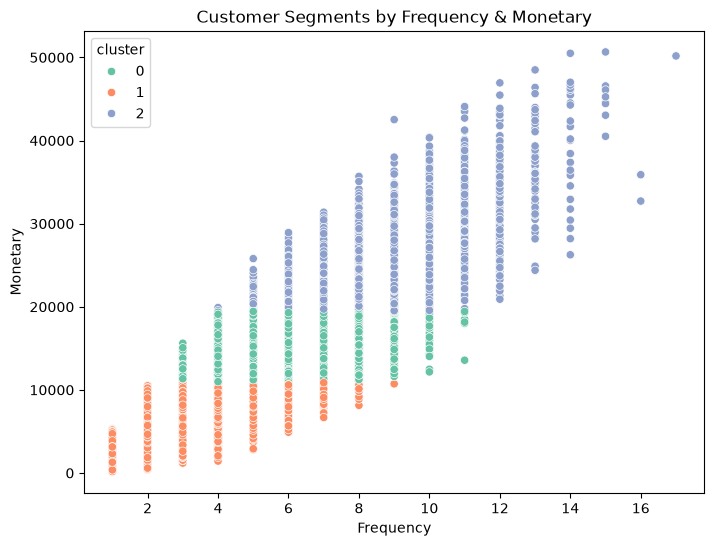

In [24]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Step 1: Feature Engineering
today = datetime(2026, 8, 10)
df["purchase_date"] = pd.to_datetime(df["purchase_date"])
df["recency"] = (today - df["purchase_date"]).dt.days

# Step 2: RFM Aggregation
rfm = df.groupby("customer_id").agg({
    "recency": "min",
    "purchase_date": "count",
    "total_purchase_amount": "sum"
}).rename(columns={
    "purchase_date": "frequency",
    "total_purchase_amount": "monetary"
})

# Step 3: Churn Flag
rfm["churn_flag"] = np.where(rfm["recency"] > 90, 1, 0)

# Step 4: Clustering (example with 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
rfm["cluster"] = kmeans.fit_predict(rfm[["frequency", "monetary"]])

# Step 5: Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="frequency", y="monetary", hue="cluster", palette="Set2")
plt.title("Customer Segments by Frequency & Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()


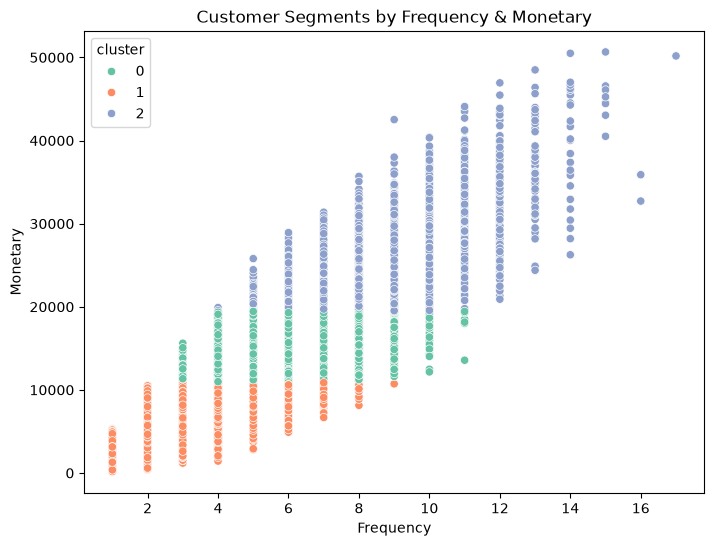

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 6: Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="frequency", y="monetary", hue="cluster", palette="Set2")
plt.title("Customer Segments by Frequency & Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

# Save the figure as a PNG file
plt.savefig("customer_segments.png", dpi=300, bbox_inches="tight")

# Optionally show it in the notebook
plt.show()


In [27]:
# Step 7: Cohort Retention Analysis
# Convert purchase_date to monthly period
df["order_month"] = df["purchase_date"].dt.to_period("M")

In [28]:
# Cohort month = first purchase month per customer
df["cohort_month"] = df.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")


In [29]:
# Count unique customers per cohort/order month
cohort_data = df.groupby(["cohort_month", "order_month"])["customer_id"].nunique().reset_index()



In [30]:
# Pivot to create cohort counts table
cohort_counts = cohort_data.pivot(index="cohort_month", columns="order_month", values="customer_id")

In [31]:
# Cohort sizes = first column
cohort_sizes = cohort_counts.iloc[:, 0]


In [32]:
# Retention = divide each column by cohort size
retention = cohort_counts.divide(cohort_sizes, axis=0)

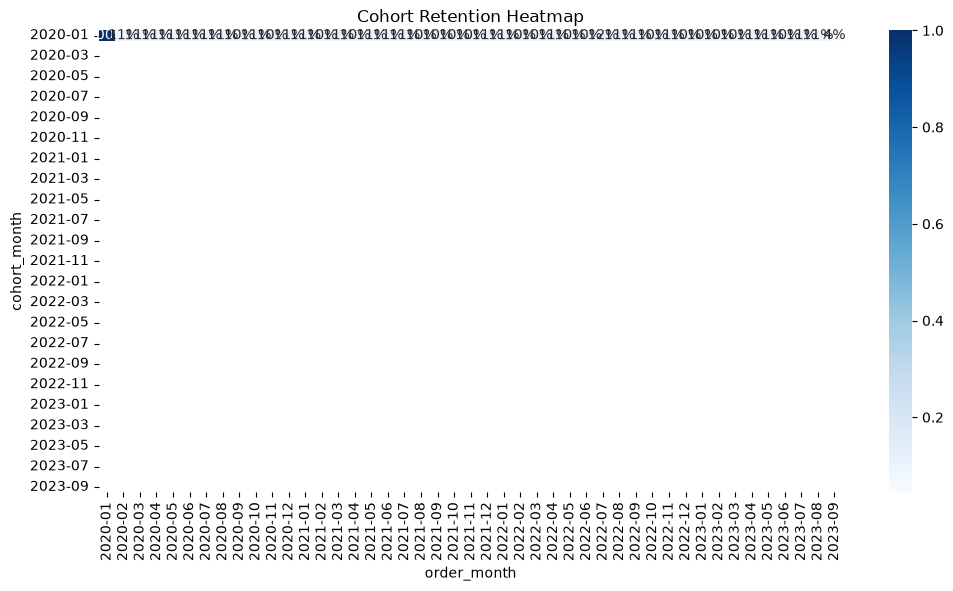

In [33]:
# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Heatmap")
plt.show()


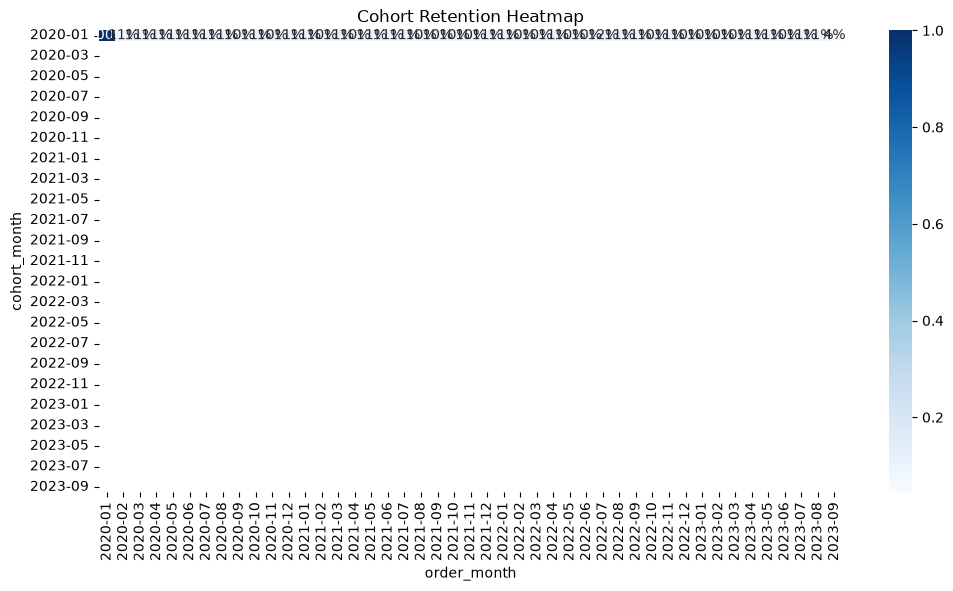

In [34]:
# Step 7: Cohort Retention Analysis
df["order_month"] = df["purchase_date"].dt.to_period("M")
df["cohort_month"] = df.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")

cohort_data = df.groupby(["cohort_month","order_month"])["customer_id"].nunique().reset_index()
cohort_counts = cohort_data.pivot(index="cohort_month", columns="order_month", values="customer_id")

cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Heatmap")

# 🔽 Save heatmap as image file
plt.savefig("cohort_retention_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


In [35]:
# Step 8: Churn Analysis
churn_rate = rfm["churn_flag"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")
# Cohort month = first purchase month per customer
df["cohort_month"] = df.groupby("customer_id")["purchase_date"].transform("min").dt.to_period("M")



Overall churn rate: 100.00%


In [36]:
# Count unique customers per cohort/order month
cohort_data = df.groupby(["cohort_month", "order_month"])["customer_id"].nunique().reset_index()



In [37]:
# Pivot to create cohort counts table
cohort_counts = cohort_data.pivot(index="cohort_month", columns="order_month", values="customer_id")


In [38]:
# Cohort sizes = first column
cohort_sizes = cohort_counts.iloc[:, 0]


In [39]:
# Retention = divide each column by cohort size
retention = cohort_counts.divide(cohort_sizes, axis=0)



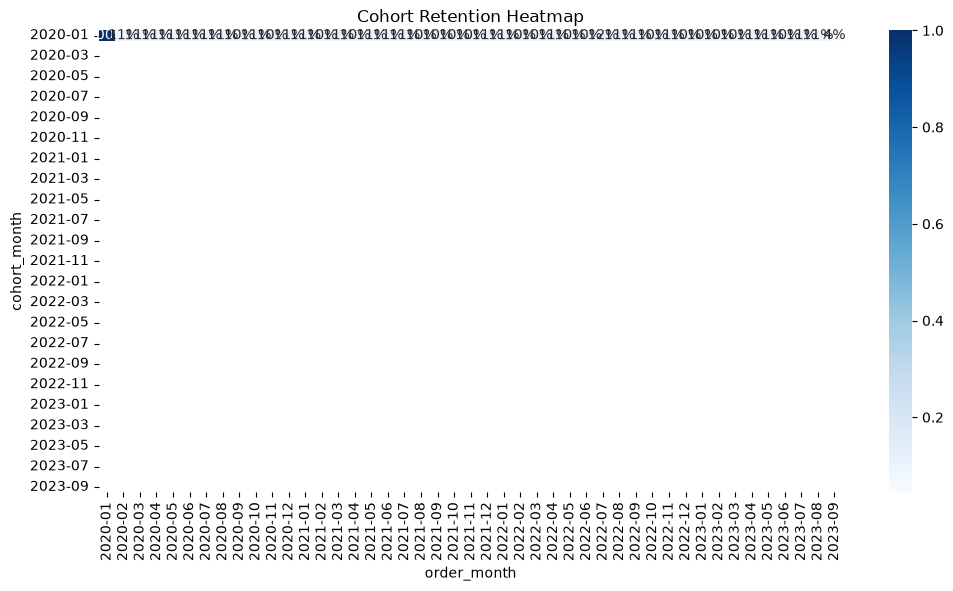

In [40]:
# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Heatmap")
plt.show()


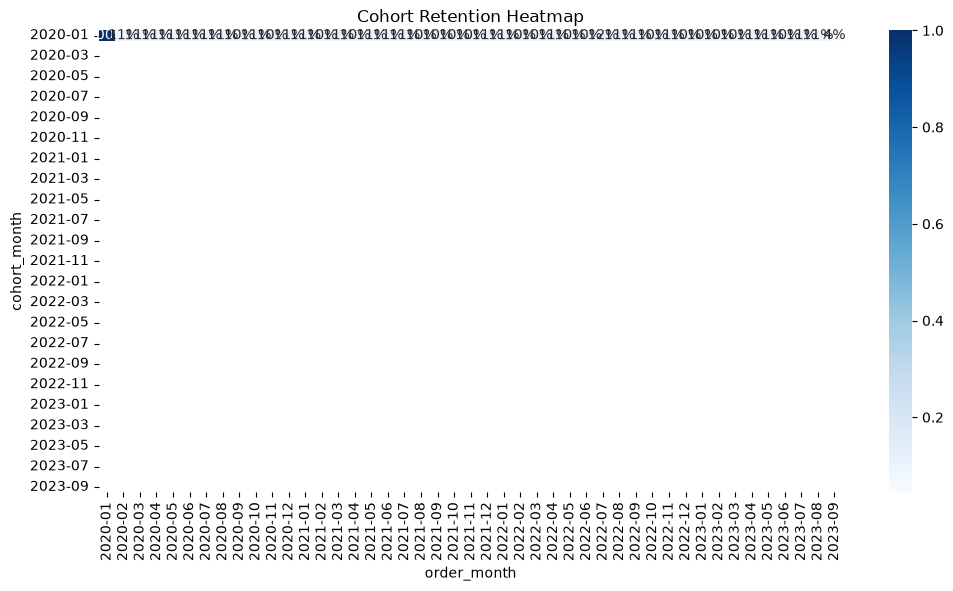

In [41]:
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Heatmap")

# 🔽 Save the heatmap as a file
plt.savefig("cohort_retention_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


In [42]:
# Step 8: Churn Analysis
churn_rate = rfm["churn_flag"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")


Overall churn rate: 100.00%


In [44]:
!pip install fpdf


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40723 sha256=f6f7fb7a8a654707337fd3816185c0a81d9148237e7af358d09957e8aa029ce5
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\77\a7\ad\85c9cac940930d61dad2d2bf19c550f172d2d7ec7c3c17af2a
Successfully built fpdf


In [46]:
# Scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="frequency", y="monetary", hue="cluster", palette="Set2")
plt.title("Customer Segments by Frequency & Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.savefig("scatterplot.png", dpi=300, bbox_inches="tight")  # 🔽 Save image
plt.close()

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Heatmap")
plt.savefig("heatmap.png", dpi=300, bbox_inches="tight")  # 🔽 Save image
plt.close()


In [47]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()

pdf.set_font("Arial", 'B', 16)
pdf.cell(0, 10, "Customer Segmentation & Retention Report", ln=True, align="C")
pdf.ln(10)

pdf.set_font("Arial", size=12)
report_text = """
Executive Summary:
This analysis applies RFM modeling, churn flags, clustering, and cohort retention.
Results highlight clear customer segments, retention challenges, and actionable strategies.
"""
pdf.multi_cell(0, 10, report_text)

# Add visuals
pdf.ln(5)
pdf.set_font("Arial", 'B', 14)
pdf.cell(0, 10, "Visualizations", ln=True)

pdf.image("scatterplot.png", x=10, w=180)   # ✅ Works now
pdf.ln(90)  # move down after image
pdf.image("heatmap.png", x=10, w=180)

pdf.output("customer_report.pdf")


''